# Notebook v2 — exploration

This notebook is the **source of truth** for version 2. It documents the reasoning, the experiments, and the dead ends. [`pipeline_v2.py`](pipeline_v2.py) is the clean extract of the parts that survived — if you change the modelling decisions here, port the winners over to that file.

It is written to be **self-contained**: it does not import the pipeline, so you can read it top to bottom as the story of how v2 was built.

**Punchline:** v1 trusted a random-split CV of 0.944 but only scored 0.886 on the leaderboard. The gap is _time_. Fixing the validation to respect time, then engineering and blending around that, lifted the leaderboard AUC to **0.889314 — 1st of 32 groups.**


In [9]:
import warnings

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

TRAIN_PATH = "data/Train_Data.csv"
TEST_PATH = "data/Test_Data_No_Target.csv"
TARGET = "Dropped_Course"
CHRONO_CUTOFF = "2017-01-01"  # validation window ~= 4 months, like the test window
SEED = 42


def load_raw(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, parse_dates=["Course_Start_Date"])
    for col in ("Agent_ID", "Company_ID"):
        df[col] = df[col].astype("string")
    return df

## 1. The discovery: the test set is the **<u>future</u>**

The single most important fact about this dataset. Train and test do not overlap in time — the test set begins exactly where train ends and continues four months further. So the real task is **forecasting the future**, not interpolating within a fixed period. Any validation that mixes future and past rows (like a random split) is measuring the wrong thing.


train dates: 2015-07-01 -> 2017-04-26  (63464 rows)
test  dates: 2017-04-26 -> 2017-08-31  (15866 rows)


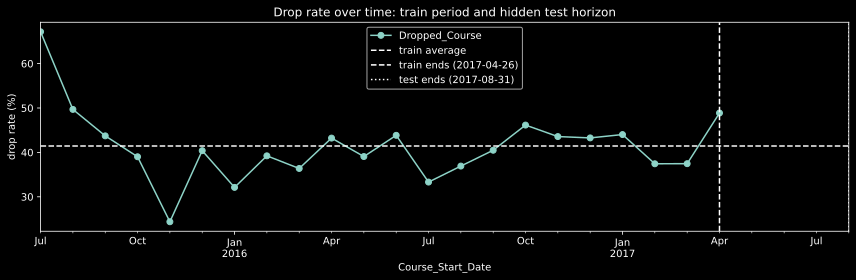

In [22]:
def show_time_ranges():
    train = load_raw(TRAIN_PATH)
    test = load_raw(TEST_PATH)

    train_end = train.Course_Start_Date.max()
    test_end = test.Course_Start_Date.max()

    print(
        f"train dates: {train.Course_Start_Date.min().date()} "
        f"-> {train_end.date()}  ({len(train)} rows)"
    )
    print(
        f"test  dates: {test.Course_Start_Date.min().date()} "
        f"-> {test_end.date()}  ({len(test)} rows)"
    )

    monthly = (
        train.set_index("Course_Start_Date").resample("MS")[TARGET].mean().mul(100)
    )

    ax = monthly.plot(marker="o", figsize=(12, 4))

    ax.axhline(train[TARGET].mean() * 100, ls="--", label="train average")
    ax.axvline(train_end, ls="--", label=f"train ends ({train_end.date()})")
    ax.axvline(test_end, ls=":", label=f"test ends ({test_end.date()})")

    ax.set_xlim(train.Course_Start_Date.min(), test_end)

    ax.set_ylabel("drop rate (%)")
    ax.set_title("Drop rate over time: train period and hidden test horizon")
    ax.legend()

    plt.tight_layout()
    plt.show()


show_time_ranges()

The ranges confirm it: train is `2015-07` $\to$ `2017-04`, test is `2017-04` $\to$ `2017-08`, with essentially zero overlap. The drop rate also drifts year to year, so a model that memorizes period-specific behavior will not transfer.


## 2. Adversarial validation: how different is test from train?

Train a classifier to tell test rows from train rows using the features (label removed). If it can separate them easily (AUC well above 0.5), the distributions have drifted and we must validate accordingly. `Client_ID` and the raw date are dropped so we measure feature drift, not the obvious time-stamp.


In [11]:
def adversarial_validation():
    train = load_raw(TRAIN_PATH).drop(columns=[TARGET])
    test = load_raw(TEST_PATH)
    combined = pd.concat(
        [train.assign(is_test=0), test.assign(is_test=1)], ignore_index=True
    )
    y = combined.pop("is_test")
    X = combined.drop(columns=["Client_ID", "Course_Start_Date"], errors="ignore")

    for col in X.select_dtypes(include=["object", "string"]).columns:
        X[col] = X[col].astype("string").str.strip().str.lower().fillna("missing")
        X[col] = X[col].astype("category").cat.codes
    X = X.fillna(-1)

    from xgboost import XGBClassifier

    Xtr, Xva, ytr, yva = train_test_split(
        X, y, test_size=0.25, random_state=SEED, stratify=y
    )
    m = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1,
    )
    m.fit(Xtr, ytr)
    auc = roc_auc_score(yva, m.predict_proba(Xva)[:, 1])
    print(
        f"adversarial AUC (train vs test): {auc:.3f}  "
        f"(0.5 = identical, 1.0 = trivially separable)"
    )
    top = (
        pd
        .Series(m.feature_importances_, index=X.columns)
        .sort_values(ascending=False)
        .head(8)
    )
    print("\ntop drift drivers:")
    print(top)


adversarial_validation()

adversarial AUC (train vs test): 0.935  (0.5 = identical, 1.0 = trivially separable)

top drift drivers:
Daily_Tuition_Cost          0.125937
Prev_Course_Dropouts        0.085177
Registration_Days_Before    0.076319
Waiting_List_Days           0.074023
Catering_Package            0.065934
Assigned_Lab_Config         0.064619
Client_Category             0.053575
Enrollment_Type             0.052758
dtype: float32


The classifier separates test from train comfortably above chance, driven by the ID / frequency-style columns — the client population shifts over time.

Conclusion: **do not trust random-split CV; validate on a future window.**


## 3. Validation methodology

We select every model and feature against a **chronological holdout**: fit on rows before `2017-01-01`, validate on the 2017 rows ($\approx$ 11.6k, a $\approx$ 4-month window matching the length of the real test window). This reproduces the leaderboard's "train on the past, score on the future" setup, so the numbers we see here move in the same direction as the real score.


## 4. Cleaning and feature engineering (source of truth)

The feature code below is what `pipeline_v2.py` extracts verbatim. Kept here so the notebook runs standalone. See the pipeline file for the per-feature rationale in prose.


In [12]:
COMMON_NANS = {
    "",
    "-",
    "--",
    ".",
    "?",
    "na",
    "n/a",
    "nan",
    "none",
    "null",
    "unknown",
    "unknonwn",
}
COUNTRY_ALIASES = {"cn": "chn"}
CAT_COLS = [
    "Origin_Country",
    "Catering_Package",
    "Welcome_Gift_Type",
    "Requested_Lab_Config",
    "Assigned_Lab_Config",
    "Enrollment_Type",
    "Lanyard_Color",
    "Client_Category",
    "Submission_Source",
    "Payment_Terms",
    "Agent_ID",
    "Company_ID",
]


def normalize_cats(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in CAT_COLS:
        s = df[col].astype("string").str.strip().str.lower()
        s = (
            s.str
            .replace(r"\band\b", "&", regex=True)
            .str.replace(r"[^a-z0-9&() .+-]+", "", regex=True)
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
        )
        df[col] = s.mask(s.isin(COMMON_NANS))
    df["Origin_Country"] = df["Origin_Country"].replace(COUNTRY_ALIASES)
    return df


def build_features(
    df: pd.DataFrame, freq_maps: dict, add_time: bool = True
) -> pd.DataFrame:
    df = normalize_cats(df)
    out = pd.DataFrame(index=df.index)

    out["Professionals_Count"] = df["Professionals_Count"]
    out["Students_Count"] = df["Students_Count"].clip(upper=10)
    out["Observers_Count"] = df["Observers_Count"]
    out["Practical_Hours"] = df["Practical_Hours"].clip(0, 12)
    out["Theory_Hours"] = df["Theory_Hours"]
    out["Registration_Days_Before"] = df["Registration_Days_Before"]
    out["Prev_Course_Dropouts"] = df["Prev_Course_Dropouts"]
    out["Prev_Course_Attended"] = df["Prev_Course_Attended"]
    out["Pre_Course_Supports_Tickets"] = df["Pre_Course_Supports_Tickets"]
    out["Physical_Course_Kits"] = df["Physical_Course_Kits"]
    out["Waiting_List_Days"] = df["Waiting_List_Days"]
    out["Registration_Changes"] = df["Registration_Changes"]
    out["Returning_Client"] = df["Returning_Client"]
    out["Daily_Tuition_Cost"] = df["Daily_Tuition_Cost"].clip(upper=600)

    d = df["Course_Start_Date"]
    out["start_month"] = d.dt.month
    out["start_dow"] = d.dt.dayofweek
    out["start_week"] = d.dt.isocalendar().week.astype(float)
    if add_time:
        out["days_since_epoch"] = (d - pd.Timestamp("2015-01-01")).dt.days

    total = (
        df["Professionals_Count"].fillna(0)
        + df["Students_Count"].clip(upper=10).fillna(0)
        + df["Observers_Count"].fillna(0)
    )
    out["total_participants"] = total
    out["prof_share"] = df["Professionals_Count"] / total.replace(0, np.nan)
    out["total_hours"] = df["Practical_Hours"].clip(0, 12) + df["Theory_Hours"]
    out["practical_share"] = df["Practical_Hours"].clip(0, 12) / out[
        "total_hours"
    ].replace(0, np.nan)
    out["cost_x_days"] = df["Daily_Tuition_Cost"].clip(upper=600) * out["total_hours"]
    out["prev_drop_rate"] = df["Prev_Course_Dropouts"] / (
        df["Prev_Course_Attended"] + 1
    )
    out["kits_per_participant"] = df["Physical_Course_Kits"] / total.replace(0, np.nan)
    out["tickets_per_participant"] = df["Pre_Course_Supports_Tickets"] / total.replace(
        0, np.nan
    )
    out["got_requested_lab"] = (
        df["Requested_Lab_Config"] == df["Assigned_Lab_Config"]
    ).astype(float)
    out["has_company_id"] = df["Company_ID"].notna().astype(int)
    out["has_agent_id"] = df["Agent_ID"].notna().astype(int)

    for col in ("Agent_ID", "Company_ID", "Origin_Country"):
        out[f"{col}_freq"] = df[col].map(freq_maps[col]).fillna(0).astype(float)

    for col in (
        "Origin_Country",
        "Catering_Package",
        "Welcome_Gift_Type",
        "Requested_Lab_Config",
        "Enrollment_Type",
        "Lanyard_Color",
        "Client_Category",
        "Submission_Source",
        "Payment_Terms",
        "Agent_ID",
    ):
        out[col] = df[col].fillna("missing").astype("category")
    return out


def make_freq_maps(*dfs):
    combined = pd.concat([normalize_cats(d) for d in dfs], ignore_index=True)
    return {
        col: combined[col].value_counts(normalize=True)
        for col in ("Agent_ID", "Company_ID", "Origin_Country")
    }


def align_categories(train_X, *others):
    for col in train_X.select_dtypes("category").columns:
        cats = train_X[col].cat.categories
        for o in others:
            cats = cats.union(o[col].cat.categories)
        train_X[col] = train_X[col].cat.set_categories(cats)
        for o in others:
            o[col] = o[col].cat.set_categories(cats)

### Dimensionality handling: why v2 avoids one-hot expansion

The course requirements ask us to address the curse of dimensionality. The risky place in this dataset is not the numeric columns; it is the categorical identifiers such as `Agent_ID`, `Company_ID`, and `Origin_Country`. A naive one-hot representation would create one dummy column per category, producing a wide sparse matrix.

v1 handled this by keeping only frequent categories and collapsing the rest into `other`. That reduces dimensions, but loses identity: many rare-but-different agents/countries become the same value. v2 takes a different route: it keeps categorical variables in native categorical form for tree-boosting models and adds compact frequency features. `Company_ID`, the highest-cardinality identifier, is not kept as a raw categorical feature at all; it is represented through `Company_ID_freq` and `has_company_id`.

The cell below compares the dimensionality of v2's native categorical representation to a hypothetical one-hot representation of the same features.


In [13]:
def dimensionality_report():
    train_raw = load_raw(TRAIN_PATH)
    test_raw = load_raw(TEST_PATH)
    freq_maps = make_freq_maps(train_raw, test_raw)

    X = build_features(train_raw, freq_maps)
    cat_cols = X.select_dtypes("category").columns

    native_dim = X.shape[1]
    onehot_dim = X.drop(columns=cat_cols).shape[1] + sum(
        X[c].nunique(dropna=False) for c in cat_cols
    )

    print(f"features with native categorical handling: {native_dim}")
    print(f"estimated dimensions after naive one-hot: {onehot_dim}")
    print(f"avoided dummy columns: {onehot_dim - native_dim}")
    print("\ncategory cardinalities:")
    print(X[cat_cols].nunique(dropna=False).sort_values(ascending=False))


dimensionality_report()

features with native categorical handling: 42
estimated dimensions after naive one-hot: 435
avoided dummy columns: 393

category cardinalities:
Agent_ID                204
Origin_Country          154
Requested_Lab_Config      9
Client_Category           8
Catering_Package          5
Enrollment_Type           5
Lanyard_Color             5
Submission_Source         5
Welcome_Gift_Type         4
Payment_Terms             4
dtype: int64


The point is not that the number of logical features becomes tiny; the point is that the model does not need a sparse dummy column for every category value. This avoids the one-hot dimensionality explosion while preserving more information than a hard top-$k$ collapse. The frequency features provide a compact numerical summary of how common an identifier is, and native categorical splits let the boosting models use category identity without manually expanding it into hundreds of binary variables.


In [14]:
def fit_predict(name, X_tr, y_tr, X_va, sample_weight=None):
    if name == "lgbm":
        from lightgbm import LGBMClassifier

        m = LGBMClassifier(
            n_estimators=700,
            learning_rate=0.03,
            num_leaves=63,
            min_child_samples=40,
            subsample=0.9,
            subsample_freq=1,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1,
        )
        cat_cols = X_tr.select_dtypes("category").columns.tolist()
        m.fit(
            X_tr,
            y_tr,
            sample_weight=sample_weight,
            categorical_feature=cat_cols,
        )
        return m.predict_proba(X_va)[:, 1]
    if name == "xgb":
        from xgboost import XGBClassifier

        m = XGBClassifier(
            n_estimators=700,
            learning_rate=0.03,
            max_depth=6,
            min_child_weight=5,
            subsample=0.9,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            enable_categorical=True,
            tree_method="hist",
            eval_metric="auc",
            random_state=SEED,
            n_jobs=-1,
        )
        m.fit(X_tr, y_tr, sample_weight=sample_weight)
        return m.predict_proba(X_va)[:, 1]
    from catboost import CatBoostClassifier

    cat_idx = [
        i for i, c in enumerate(X_tr.columns) if str(X_tr[c].dtype) == "category"
    ]
    X_tr2, X_va2 = X_tr.copy(), X_va.copy()
    for c in X_tr2.columns[cat_idx]:
        X_tr2[c] = X_tr2[c].astype(str)
        X_va2[c] = X_va2[c].astype(str)
    m = CatBoostClassifier(
        iterations=1200,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=3.0,
        random_seed=SEED,
        verbose=False,
        eval_metric="AUC",
        cat_features=cat_idx,
    )
    m.fit(X_tr2, y_tr, sample_weight=sample_weight)
    return m.predict_proba(X_va2)[:, 1]


def rank_avg(preds):
    from scipy.stats import rankdata

    return np.mean([rankdata(p) / len(p) for p in preds], axis=0)

### Why LightGBM and CatBoost were added

The course explicitly allows and encourages using tools beyond the lecture material, as long as the modelling decisions are explained. XGBoost, LightGBM, and CatBoost are all gradient-boosted decision-tree models: each builds an ensemble of trees sequentially, where later trees try to correct the mistakes of earlier trees.

We used them together for three reasons. First, tabular business data with nonlinear interactions is a strong use case for boosted trees. Second, their native or explicit categorical handling helps avoid a large one-hot-encoded feature matrix. Third, the models have slightly different implementations and inductive biases, so averaging their ranked predictions reduces dependence on one specific model's errors. The final blend was kept only because it improved chronological validation, not because the random split looked good.


## 5. Experiments on the chronological holdout

Each row below is fit on pre-2017 data and scored on the 2017 window. This is where the modelling decisions were made. Read the printed table as "what actually helps when predicting the future."


In [ ]:
def run_experiments():
    train_raw = load_raw(TRAIN_PATH)
    test_raw = load_raw(TEST_PATH)
    freq_maps = make_freq_maps(train_raw, test_raw)

    cutoff = pd.Timestamp(CHRONO_CUTOFF)
    tr_raw = train_raw[train_raw["Course_Start_Date"] < cutoff]
    va_raw = train_raw[train_raw["Course_Start_Date"] >= cutoff]
    print(
        f"chrono split: fit={len(tr_raw)}  val={len(va_raw)}  "
        f"val drop rate={va_raw[TARGET].mean():.3f}\n"
    )
    y_tr, y_va = tr_raw[TARGET].values, va_raw[TARGET].values

    # --- (a) baseline: no time index -------------------------------------
    Xt = build_features(tr_raw, freq_maps, add_time=False)
    Xv = build_features(va_raw, freq_maps, add_time=False)
    align_categories(Xt, Xv)
    base = {}
    for name in ("lgbm", "xgb", "cat"):
        base[name] = fit_predict(name, Xt, y_tr, Xv)
        print(f"{name:>14}: {roc_auc_score(y_va, base[name]):.4f}")
    print(f"{'blend3':>14}: {roc_auc_score(y_va, rank_avg(list(base.values()))):.4f}")

    # recency weighting (rejected): down-weight old rows
    age = (tr_raw['Course_Start_Date'].max() - tr_raw['Course_Start_Date']).dt.days
    w = np.power(0.5, age / 365.0).values
    p = fit_predict("lgbm", Xt, y_tr, Xv, sample_weight=w)
    print(f"{'lgbm+recency':>14}: {roc_auc_score(y_va, p):.4f}   (rejected)")

    # --- (b) with the linear time index ----------------------------------
    Xt2 = build_features(tr_raw, freq_maps, add_time=True)
    Xv2 = build_features(va_raw, freq_maps, add_time=True)
    align_categories(Xt2, Xv2)
    time_preds = {}
    for name in ("lgbm", "xgb", "cat"):
        time_preds[name] = fit_predict(name, Xt2, y_tr, Xv2)
        print(f"{name + '+time':>14}: {roc_auc_score(y_va, time_preds[name]):.4f}")
    blend_t = rank_avg(list(time_preds.values()))
    print(f"{'blend3+time':>14}: {roc_auc_score(y_va, blend_t):.4f}   <- chosen")

    # --- (c) reference: optimistic random split --------------------------
    tr_r, va_r = train_test_split(
        train_raw, test_size=0.2, random_state=SEED, stratify=train_raw[TARGET]
    )
    Xtr = build_features(tr_r, freq_maps)
    Xvr = build_features(va_r, freq_maps)
    align_categories(Xtr, Xvr)
    p = fit_predict("lgbm", Xtr, tr_r[TARGET].values, Xvr)
    print(
        f"\n{'random split':>14}: {roc_auc_score(va_r[TARGET].values, p):.4f}"
        f"   <- optimistic, do NOT trust"
    )


run_experiments()

chrono split: fit=51822  val=11642  val drop rate=0.420

          lgbm: 0.9106
           xgb: 0.9098
           cat: 0.9095
        blend3: 0.9118
  lgbm+recency: 0.9104   (rejected)
     lgbm+time: 0.9143
      xgb+time: 0.9137
      cat+time: 0.9113
   blend3+time: 0.9157   <- chosen

   lgbm random: 0.9638   <- optimistic, do NOT trust


### What the table shows

| Config                                  | Chrono AUC                              |
| --------------------------------------- | --------------------------------------- |
| LightGBM / XGBoost / CatBoost (no time) | $\approx$ 0.910 / 0.910 / 0.910         |
| Blend of 3 (no time)                    | $\approx$ 0.912                         |
| + recency sample weights                | $\approx$ 0.910 — **rejected**, no gain |
| + linear time index (per model)         | $\approx$ 0.914                         |
| **Blend of 3 + time index**             | **$\approx$ 0.916 — chosen**            |
| LightGBM, random split                  | $\approx$ 0.96 — optimistic, ignore     |

**The counterintuitive win — the time index.** Intuition says "trees can't extrapolate, drop the date" (this is exactly what v1 did). But on a strictly-future holdout, adding `days_since_epoch` _helped every model_.

Future rows fall past every split threshold and land in the most-recent leaf, so the model scores them like the latest regime instead of averaging over 2015-2016. It only shows up because we validate on the future — a random split would have hidden it.

**Rejected:** recency sample-weighting (half-life 365d/180d) — the time index already captures the trend, so re-weighting added nothing.


## 6. Head-to-head vs the v1 pipeline

To be sure v2 is really better (and not just better-looking under a different metric), the v1 approach (drop the date, top-N collapse, one-hot, single XGBoost) is scored on the _same_ two splits as v2.

A compact reproduction of v1 is inlined here so this notebook stays standalone; the real thing lives in [pipeline_v1.py](pipeline_v1.py).


In [16]:
def v1_repro_score(tr_raw, va_raw):
    from sklearn.preprocessing import OneHotEncoder
    from xgboost import XGBClassifier

    def prep(df, ref):
        df, ref = df.copy(), ref.copy()
        for c in ("Agent_ID", "Company_ID"):
            df[c] = df[c].astype("string").astype(object)
            ref[c] = ref[c].astype("string").astype(object)
        for c in df.select_dtypes(include="object").columns:
            df[c] = df[c].astype(str).str.strip().str.lower().replace({"nan": np.nan})
            ref[c] = ref[c].astype(str).str.strip().str.lower().replace({"nan": np.nan})
        df["Origin_Country"] = df["Origin_Country"].replace({"cn": "chn"})
        num = df.select_dtypes(include=["int64", "float64"]).columns.drop(
            TARGET, errors="ignore"
        )
        df[num] = df[num].fillna(ref[num].median())
        df = df.drop(columns=["Course_Start_Date"])
        for col, thr in (("Agent_ID", 300), ("Origin_Country", 300)):
            keep = set(ref[col].value_counts()[lambda s: s >= thr].index)
            df[col] = df[col].where(df[col].isin(keep), "other").fillna("missing")
        df = df.drop(columns=["Company_ID"])
        df["recived_requested_lab"] = (
            df["Requested_Lab_Config"] == df["Assigned_Lab_Config"]
        ).astype(int)
        df = df.drop(
            columns=[
                "Assigned_Lab_Config",
                "Lanyard_Color",
                "Requested_Lab_Config",
                "Returning_Client",
                "Welcome_Gift_Type",
            ]
        )
        df["Students_Count"] = df["Students_Count"].clip(upper=3)
        df["Practical_Hours"] = df["Practical_Hours"].clip(0, 8)
        df["Daily_Tuition_Cost"] = df["Daily_Tuition_Cost"].clip(upper=500)
        for c in df.select_dtypes(include="object").columns:
            df[c] = df[c].fillna("missing")
        return df

    tr, va = prep(tr_raw, tr_raw), prep(va_raw, tr_raw)
    Xt, yt = tr.drop(columns=[TARGET]), tr[TARGET]
    Xv, yv = va.drop(columns=[TARGET]), va[TARGET]
    cat = Xt.select_dtypes(include="object").columns
    enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False).set_output(
        transform="pandas"
    )
    Xt = pd.concat(
        [
            Xt.drop(columns=cat).reset_index(drop=True),
            enc.fit_transform(Xt[cat]).reset_index(drop=True),
        ],
        axis=1,
    )
    Xv = pd.concat(
        [
            Xv.drop(columns=cat).reset_index(drop=True),
            enc.transform(Xv[cat]).reset_index(drop=True),
        ],
        axis=1,
    )

    # XGBoost rejects feature names containing [, ], or <.
    # OneHotEncoder can create such names from raw category text, so we sanitize
    # the reproduced v1 feature names before fitting.
    safe_cols = [
        str(c).replace("[", "(").replace("]", ")").replace("<", "lt")
        for c in Xt.columns
    ]
    Xt.columns = safe_cols
    Xv.columns = safe_cols

    m = XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1,
    )
    m.fit(Xt, yt)
    return roc_auc_score(yv, m.predict_proba(Xv)[:, 1])


def v2_score(tr_raw, va_raw):
    fm = make_freq_maps(tr_raw, va_raw)
    Xt = build_features(tr_raw, fm)
    Xv = build_features(va_raw, fm)
    align_categories(Xt, Xv)
    preds = [
        fit_predict(n, Xt, tr_raw[TARGET].values, Xv) for n in ("lgbm", "xgb", "cat")
    ]
    return roc_auc_score(va_raw[TARGET].values, rank_avg(preds))


def compare_v1_v2():
    raw = load_raw(TRAIN_PATH)
    tr_r, va_r = train_test_split(
        raw, test_size=0.2, random_state=SEED, stratify=raw[TARGET]
    )
    tr_c = raw[raw["Course_Start_Date"] < CHRONO_CUTOFF]
    va_c = raw[raw["Course_Start_Date"] >= CHRONO_CUTOFF]
    print(f"{'':<12}{'random split':>14}{'chrono split':>14}")
    print(
        f"{'v1':<12}{v1_repro_score(tr_r, va_r):>14.4f}{v1_repro_score(tr_c, va_c):>14.4f}"
    )
    print(f"{'v2':<12}{v2_score(tr_r, va_r):>14.4f}{v2_score(tr_c, va_c):>14.4f}")


compare_v1_v2()

              random split  chrono split
v1                  0.9412        0.9066
v2                  0.9620        0.9149


### Result (typical run)

| Pipeline                  | Random 80/20    | Chrono holdout  |
| ------------------------- | --------------- | --------------- |
| v1 (notebook_v1 approach) | $\approx$ 0.940 | $\approx$ 0.905 |
| v2 (this notebook)        | $\approx$ 0.962 | $\approx$ 0.916 |

v2 wins on **both** protocols, so the improvement is real and not an artifact of switching metrics. Calibrating against the known leaderboard gap (v1: 0.905 chrono → 0.886 real) suggests v2's ~0.916 chrono maps to roughly 0.89-0.90 on the leaderboard — which is what we saw: **0.889314**.


## Model interpretation with SHAP

The final submission uses a rank-average blend. For interpretation, we analyze
one representative model: LightGBM + time. This keeps the explanation clean and
matches the requirement to choose one model for deeper analysis.


LightGBM+time chrono AUC: 0.9143; SHAP sample size: 2000


,feature,mean_abs_shap
0,Payment_Terms,1.795957
1,Origin_Country,0.817795
2,Agent_ID,0.614655
3,days_since_epoch,0.549641
4,tickets_per_participant,0.405572
5,Registration_Days_Before,0.340751
6,prev_drop_rate,0.264592
7,Origin_Country_freq,0.254313
8,Enrollment_Type,0.251744
9,Client_Category,0.222782


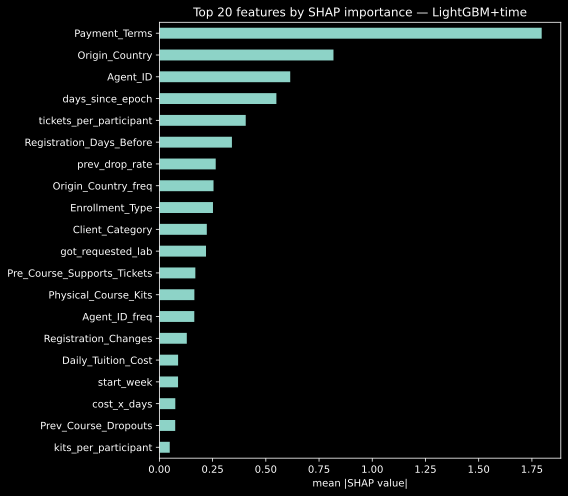

In [23]:
def shap_lgbm_importance(k=20, sample_size=2000, force=False):
    import pickle
    from pathlib import Path

    import shap
    from lightgbm import LGBMClassifier

    cache_path = Path("cache/shap_lgbm_chrono.pkl")
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    if cache_path.exists() and not force:
        with cache_path.open("rb") as f:
            result = pickle.load(f)
    else:
        train_raw = load_raw(TRAIN_PATH)
        test_raw = load_raw(TEST_PATH)
        freq_maps = make_freq_maps(train_raw, test_raw)

        cutoff = pd.Timestamp(CHRONO_CUTOFF)
        tr_raw = train_raw[train_raw["Course_Start_Date"] < cutoff]
        va_raw = train_raw[train_raw["Course_Start_Date"] >= cutoff]

        Xtr = build_features(tr_raw, freq_maps, add_time=True)
        Xva = build_features(va_raw, freq_maps, add_time=True)
        align_categories(Xtr, Xva)

        model = LGBMClassifier(
            n_estimators=700,
            learning_rate=0.03,
            num_leaves=63,
            min_child_samples=40,
            subsample=0.9,
            subsample_freq=1,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1,
        )

        cat_cols = Xtr.select_dtypes("category").columns.tolist()
        model.fit(Xtr, tr_raw[TARGET].values, categorical_feature=cat_cols)

        X_sample = Xva.sample(min(sample_size, len(Xva)), random_state=SEED)

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]

        importance = (
            pd
            .DataFrame({
                "feature": X_sample.columns,
                "mean_abs_shap": np.abs(shap_values).mean(axis=0),
            })
            .sort_values("mean_abs_shap", ascending=False)
            .reset_index(drop=True)
        )

        result = {
            "importance": importance,
            "sample_size": len(X_sample),
            "chrono_auc": roc_auc_score(
                va_raw[TARGET].values,
                model.predict_proba(Xva)[:, 1],
            ),
        }

        with cache_path.open("wb") as f:
            pickle.dump(result, f)

    print(
        f"LightGBM+time chrono AUC: {result['chrono_auc']:.4f}; "
        f"SHAP sample size: {result['sample_size']}"
    )

    top = result["importance"].head(k)
    try:
        display(top)
    except NameError:
        print(top.to_string(index=False))

    ax = top.sort_values("mean_abs_shap").plot.barh(
        x="feature",
        y="mean_abs_shap",
        legend=False,
        figsize=(8, max(4, 0.35 * len(top))),
    )
    ax.set_xlabel("mean |SHAP value|")
    ax.set_ylabel("")
    ax.set_title(f"Top {k} features by SHAP importance — LightGBM+time")
    plt.tight_layout()
    plt.show()

    return result


FORCE_RECOMPUTE_SHAP = False
shap_result = shap_lgbm_importance(k=20, sample_size=2000, force=FORCE_RECOMPUTE_SHAP)

## 7. Conclusions → what `pipeline_v2.py` implements

1. Validate on a **chronological** future window, never a random split.
2. Full categorical **normalization** + label-free **frequency encoding**.
3. Composition / ratio / history features + a **linear time index**.
4. **Blend** LightGBM + XGBoost + CatBoost by rank average.
5. Refit on all rows and write `data/Group_27_Submission.csv`.

### Ideas for v3

- Proper time-series CV (multiple rolling chrono folds) for tuning.
- Target/leave-one-out encoding of Agent/Company (careful, leaky).
- Investigate the `Payment_Terms == "Prepaid (Non-Refundable)"` signal — very
  strong; confirm it is not label leakage before leaning on it further.


In [17]:
if __name__ == "__main__":
    # running as a script re-executes the experiment blocks above
    pass